# Lesson 166 · RDB-PFN synthetic relational priors

Standalone lesson, real checkpoint, three live learner mechanisms, and complete saved-evidence replay. Requires NumPy and PyTorch; no cloud/API calls during the default run. Portable diagrams and all default-run inputs are embedded. Public course links become available only after publication.

<div class="lab-access"><strong>Lesson package</strong> · <a href="https://avistian.github.io/relational/labs/0166-rdb-pfn-synthetic-relational-priors.ipynb">Student notebook</a> · <a href="https://avistian.github.io/relational/labs/solutions/0166-rdb-pfn-synthetic-relational-priors.ipynb">Solution</a> · <a href="https://avistian.github.io/relational/labs/html/0166-rdb-pfn-synthetic-relational-priors.html">Executed author preview</a><br><a href="https://avistian.github.io/relational/reference/rdb-pfn.html">Quick reference</a> · <a href="https://avistian.github.io/relational/labs/l166-reproduction.md">Full reproduction contract</a> · <a href="https://avistian.github.io/relational/labs/evidence/l166/report.md">Measured results</a></div>

## 1 · Where do the frozen weights come from?

**Your tangible win:** trace how a synthetic relationship becomes a useful input to a frozen predictor, then defend one reproduced result without claiming to have reproduced its pretraining. Allow 25 minutes for the reading and trace; use a separate session for the notebook and defense.

[Lesson 165](https://avistian.github.io/relational/lessons/0165-kumorfm-in-context-relational-learning.html) explained how a model can adapt by reading labeled context while keeping its weights fixed. Its historical KumoRFM experiment remained unrun because matching artifacts were unresolved. That leaves another question: **what could train those weights when real relational databases are scarce or private?** RDB-PFN proposes generating synthetic databases and learning from prediction tasks made from them. Here, released code and checkpoints let us test a selected result. [Paper §§1,5](https://arxiv.org/html/2603.03805v5).

Retrieve the PFN idea from [Lesson 061](https://avistian.github.io/relational/lessons/0061-prior-data-fitted-networks.html): a generator supplies many small supervised problems. A shared model repeatedly sees a labeled support set and predicts held-out labels. Training adjusts its weights across problems. At deployment, a new support set describes the new problem; inference need not optimize the weights again. If you cannot explain support versus query, revisit the first two sections of Lesson 165. L165b is a planned comparison, not an assumed prerequisite.



**Reading route.** First trace a parent value into its children's summaries. Then trace those summaries through feature attention and support-row attention. Only after those paths are clear, read the benchmark table and its provenance limits. **PFN** expands to prior-data fitted network: its pretraining tasks express a prior, or assumptions about the problems it will later encounter.

“Synthetic” alone does not solve transfer. The generator must produce dependencies that help on real inputs. Independent random tables with valid keys can still omit the useful relationship between a customer's past orders and a future outcome. The learning question becomes: **which relational regularities does the prior expose?**

## 2 · Generate a relationship, then hide its answer

**Generator vocabulary.** A latent value is hidden from the predictor. A structural causal model (**SCM**) generates values through specified dependencies plus random noise. An acyclic schema has no directed cycle of parent links. A support/query **episode** is one small prediction problem used during pretraining. These terms describe how tasks are made; they do not certify causal knowledge about a real database.

The paper separates the generator into schema, structure and content. The schema fixes which tables may refer to which parents. Structure selects actual parent rows and latent states. Content fills the remaining cells, with an optional row-GNN variant propagating information. Tasks then select targets and form support/query episodes. The proposed theoretical coverage depends on assumptions including acyclic schemas; it is not a guarantee that every business database is represented. [Paper §§4–5, Appendix E](https://arxiv.org/html/2603.03805v5).

<figure class="route-figure" tabindex="0">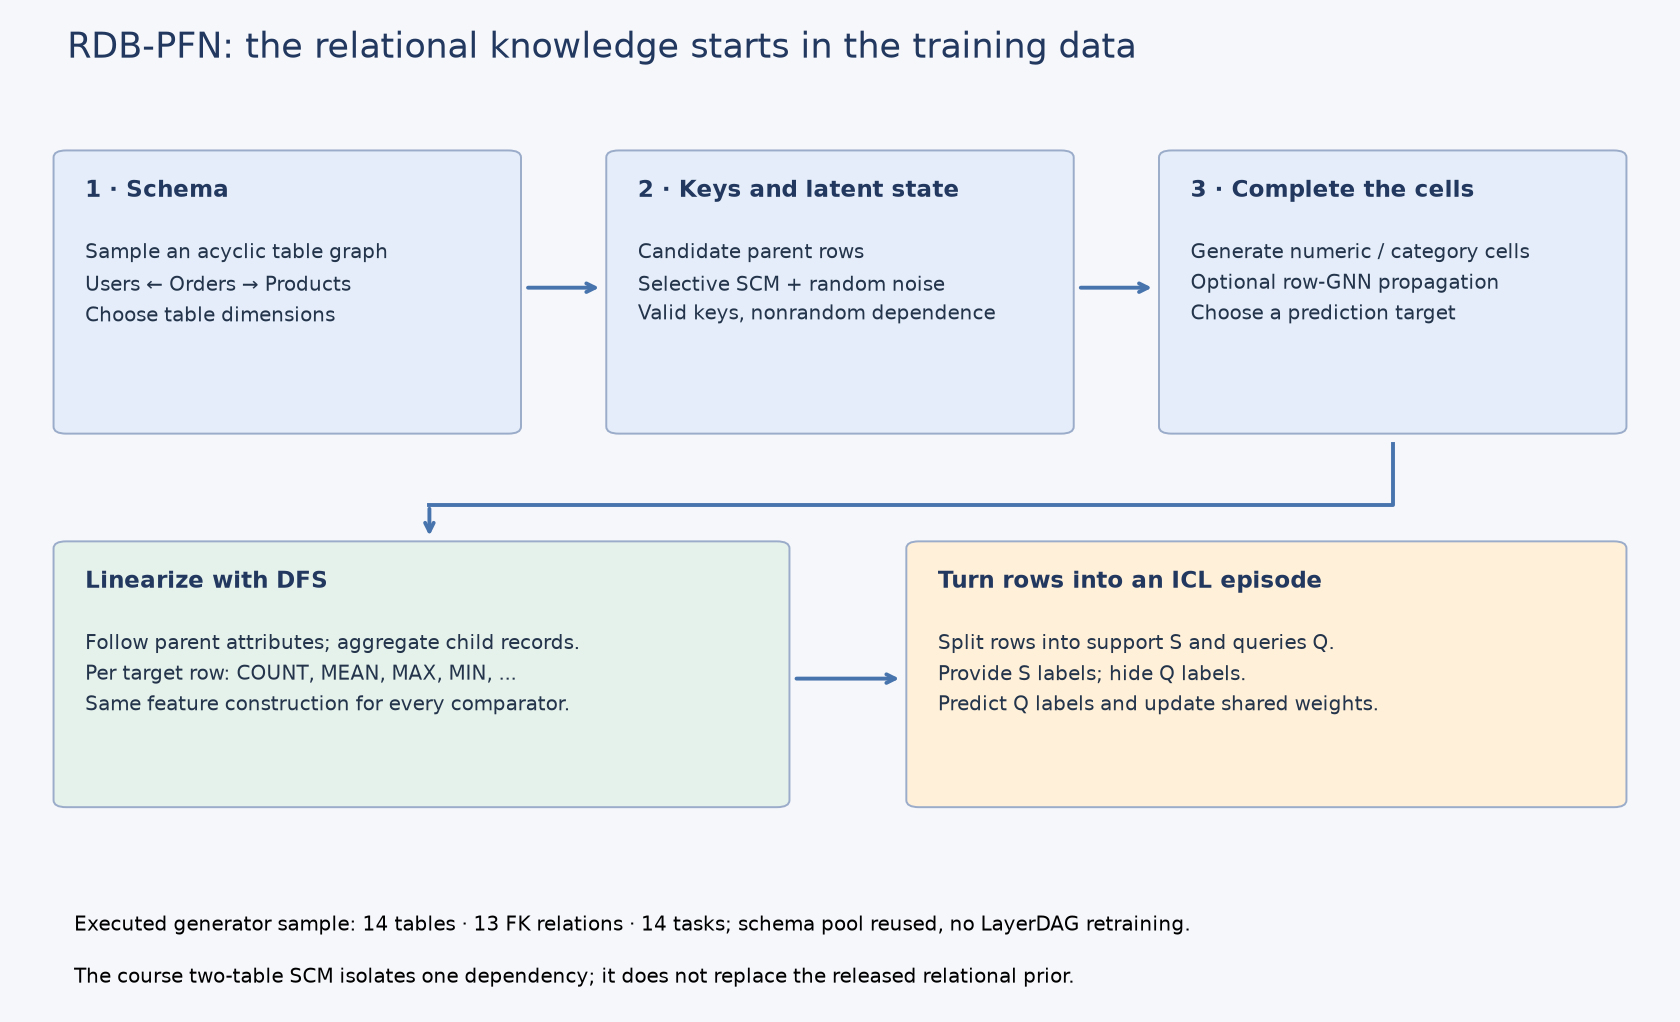<figcaption>Schema → keys and latent states → cells → DFS → support/query prediction episodes. The original sampled database and tiny course SCM are separate artifacts.</figcaption></figure>

Start with a small **course example**, not the full released generator. A parent has an unobserved value `z`. Each child stores a valid parent key and a value `a × z[parent] + noise`. The coefficient `a` controls how much of the parent's signal is carried by its children. Setting `a=0` removes that path while preserving the keys and noise draws. Merely keeping the schema would not preserve the predictive dependency.

```python
latent = rng.normal(size=parents)
foreign_keys = rng.integers(parents, size=children)
noise = rng.normal(scale=0.2, size=children)
child_value = strength * latent[foreign_keys] + noise
```

Deep Feature Synthesis (**DFS**) turns related records into a row vector. It can copy parent attributes into a child row and summarize children at their parent. For parent A with child values 2 and 6, `COUNT=2` and `MEAN=4`. For parent B with value 10, the result is `[1,10]`. Child order must not change either summary. Our course convention maps a parent with no children to `[0,0]`; the released pipeline handles missing features through its own support-only median step. [Paper §5.2; source preprocessing](https://avistian.github.io/relational/labs/sources/l166/upstream/data_preprocessing/README.md).

The relational information therefore reaches the model **through the generated dependencies and DFS features**. This version does not feed the raw foreign-key graph directly into the inference transformer. Comparing RDB-PFN with a tabular model on raw root attributes would confound representation and prior. Our three arms get the same DFS matrix.

**Executed source experiment:** one original generator draw produced 14 tables, 13 FK relationships and 14 tasks. We checked every generated key. It reused the released schema pool; it did not retrain LayerDAG or recreate the full pretraining corpus. [Generator receipt](https://avistian.github.io/relational/labs/evidence/l166/generator.json).

## 3 · Model architecture: cross features, then cross examples

> **In plain terms.** First let the columns within one row interact. Then let that row compare itself with labeled support rows. Repeat, and read the query's output. Keeping these two attention directions separate makes the information boundary easier to see.

<figure class="route-figure" tabindex="0">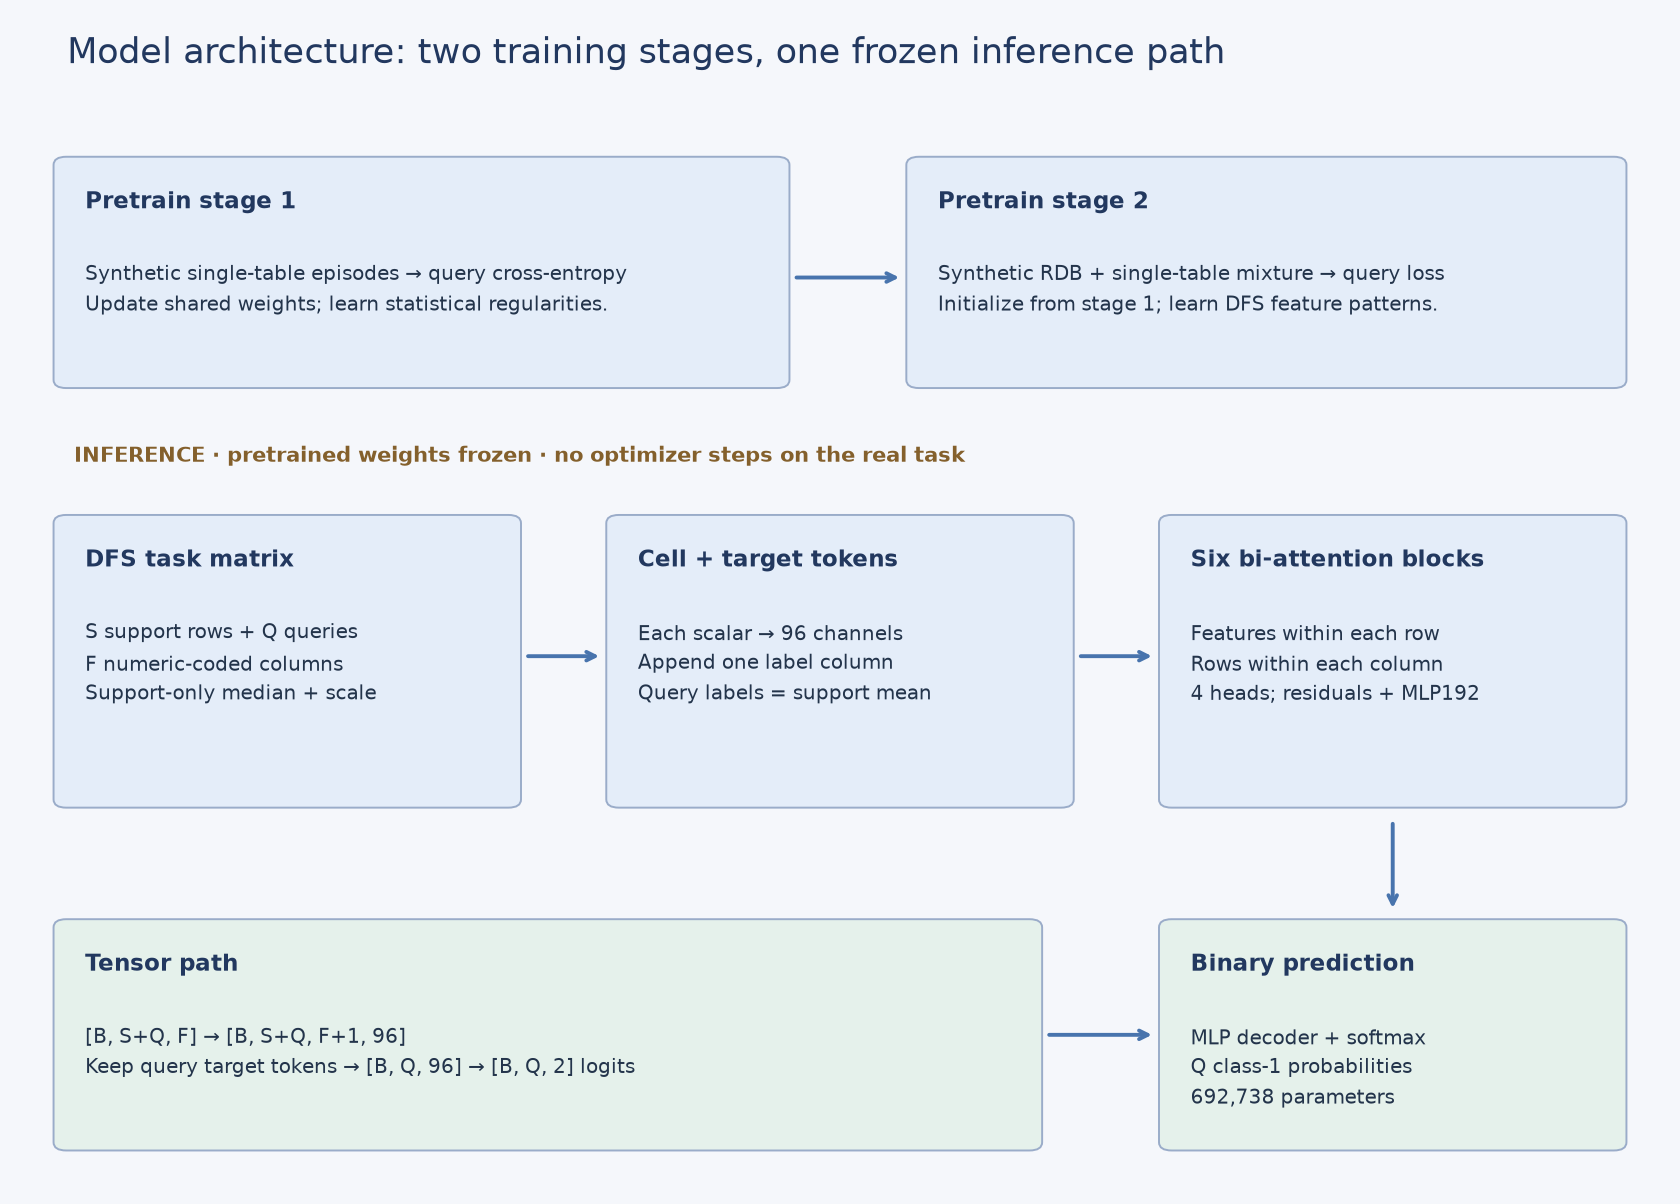<figcaption>Released numeric base: six bi-attention blocks, width 96, four heads, MLP width 192 and binary target-token decoder. Stage 2 also mixes single-table tasks. Pretraining is not rerun here.</figcaption></figure>

Read the path with one database task in mind. Suppose `S=512` support rows and `Q=702` queries. Each row has `F` DFS features. Median imputation and feature normalization use support statistics. A shared linear projection turns every scalar into 96 channels. The model appends one additional token column for the label: known support labels, support-label mean in query slots. Query labels never enter this tensor. [Released base model](https://avistian.github.io/relational/labs/sources/l166/upstream/model_pretrain/src/models.py).

**Decode the diagram.** Median imputation replaces a missing value with the middle observed support value for that feature. A channel is one coordinate of a token vector. MLP means a small feed-forward neural network; GELU is its smooth nonlinear activation. A residual connection adds an update to the existing vector, and layer normalization rescales its coordinates. Logits are unnormalized class scores; softmax turns them into probabilities that sum to one. In the tensor path, B counts batched tasks, S support rows, Q queries and F features.

One block performs two attention operations and a feed-forward update:

1. **Feature attention:** within each row, the feature and label tokens exchange information. A support label can affect its own feature tokens; a query gets only its placeholder label.
2. **Row attention:** within each column, every receiving row attends to **support rows only**. This lets a query compare its DFS pattern with labeled examples without reading other queries as keys or values.
3. **Feed-forward update:** residual connections, layer normalization and a GELU MLP transform the tokens. Repeat six blocks, then decode each query's label-column token into two logits and apply softmax.

<figure class="route-figure" tabindex="0">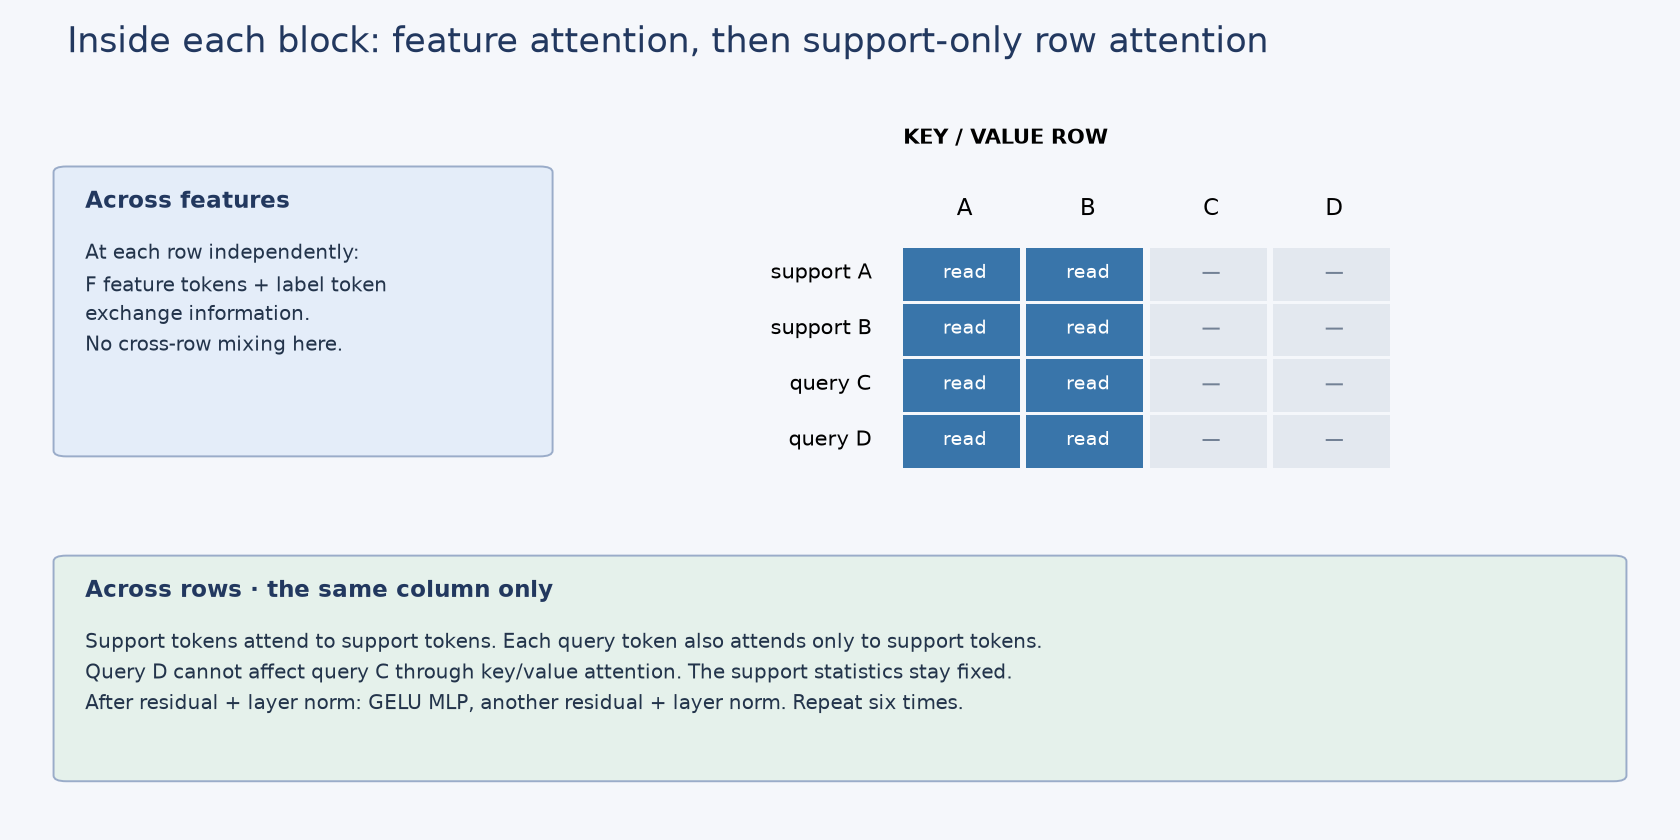<figcaption>Blue entries are visible keys and values. All row receivers read support columns only. Feature attention separately mixes tokens within each row.</figcaption></figure>

Predict: can query D change query C by becoming its attention key? No: every row reads support keys only.

The visible notebook implementation contains the whole 692,738-parameter numeric base model. These lines carry the row-attention rule; the two slices share attention weights:

```python
keys = tokens[:, :support]
support_out = row_attention(keys, keys, keys)[0]
query_out = row_attention(tokens[:, support:], keys, keys)[0]
tokens = tokens + torch.cat([support_out, query_out], dim=1)
```

Changing query D cannot change query C through row-attention keys. Changing a support label can. This distinction is testable: our checkpoint checks perturb other queries and change batching while holding support fixed. Both released RDB-PFN checkpoints match the visible implementation's checked outputs, with gradient agreement to numerical precision. [Parity receipt](https://avistian.github.io/relational/labs/evidence/l166/parity.json).

**Training versus inference.** The first training stage uses synthetic single-table tasks. The second starts from those weights and mixes relational and single-table tasks, minimizing query-label cross-entropy. The released second-stage config lists 2.2 million steps across 8 GPUs. Our evaluation loads its final checkpoint; it does not execute that training schedule. The query labels are needed for the *training loss*, but remain absent from the model's *input*. [Training config](https://avistian.github.io/relational/labs/sources/l166/upstream/model_pretrain/conf_train/RDBPFN.yaml), [loss code](https://avistian.github.io/relational/labs/sources/l166/upstream/model_pretrain/src/training.py).

## 4 · Predict an intervention before moving the controls

The explorer uses the six-parent course SCM and the **actual released RDB-PFN checkpoint**. Values are precomputed by the visible Python model, not fitted JavaScript scores. Rows 0…S−1 are support; remaining rows are queries. The binary label is the sign of the invented parent latent. We omit that latent from features and give the model only count/mean summaries.

Predict which objects change when you flip only the supplied support labels. The DFS matrix and attention mask should stay fixed. The query probabilities may change. Changing dependency strength instead keeps foreign keys fixed and changes the mean-value features. Neither intervention retrains the checkpoint.

Static baseline: dependency strength 1, four support rows, original labels. The code below reruns all 12 interventions with the actual checkpoint. Flip support labels without changing features or the attention mask.

These are mechanism traces, **not** accuracy estimates. Six invented parents cannot establish that the prior transfers. With fewer support rows, some of the same rows change roles, so compare a common query such as row 5 rather than pretending that every displayed prediction covers the same population. A probability need not move monotonically with dependency strength.

## 5 · The approved full selected experiment

We evaluated the complete **Table 9 driver-dnf, 512-context, ten-seed** selection: RDB-PFN, its single-table-only checkpoint and TabICLv1.1 with its full 32-estimator ensemble. All models received identical selected support keys and the same 702 test queries. No test-driven checkpoint choice, reduced ensemble or missing seed. [Paper Appendix F, Table 9](https://arxiv.org/html/2603.03805v5), [exact contract](https://avistian.github.io/relational/labs/l166-reproduction.md).

| Model | Paper AUROC | Fresh mean ± sample SD | Result |
|---|---:|---:|---|
| RDBPFN | 0.7219 | 0.721938 ± 0.019983 | CLOSE |
| RDBPFN_single | 0.6640 | 0.663990 ± 0.034177 | CLOSE |
| TabICLv1.1 | 0.7176 | 0.717568 ± 0.009770 | CLOSE |

Every mean rounds to the corresponding paper value. The paired mean RDB-PFN gain over the single-table checkpoint is **0.057948 AUROC**, with seed-difference SD **0.043287**. The gain over TabICLv1.1 is **0.004369**, with SD **0.019808**. These are ten support draws on one task and a shared test set, not independent databases or proof of broad superiority. The single-table comparison also changes training stage and total compute; it is not a matched-compute causal isolation of the relational prior.

Two evidence boundaries matter even with that close match:

- **Target meaning:** all 12,679 released labels are the complement of the current raw-data DNF definition on the checked keys. We retained the release for numerical replay. To interpret scores as current-definition DNF risk, complement both labels and probabilities. The column name alone is insufficient provenance.
- **Historical features:** three available MAX timestamp features stay before their owner cutoffs, and the source config requests temporal DFS. We did not regenerate every released feature from the original historical database. Availability history and exact historical preprocessing identity remain unestablished.

The independent evaluator recomputes every score and validates all 21,060 predictions against 702 complete `(driverId,date)` keys. That is complete selected **checkpoint evaluation**. Fresh foundation-model pretraining and the whole 19-task benchmark remain **NOT_RUN**. The conservative budget accounting is **$4.41**, including reservations and overhead; it is not an itemized invoice. [Evaluation audit](https://avistian.github.io/relational/labs/evidence/l166/evaluation-audit.json), [cost receipt](https://avistian.github.io/relational/labs/evidence/l166/cost.json).

## 6 · Make the explanation survive a changed example

The notebook has three live tasks: generate the two-table dependency, implement order-invariant child aggregation, and construct the support-only attention mask. Their outputs feed the checkpoint explorer. Incorrect key handling, constant aggregation and query-visible masks must fail immediate checks. The full model and complete benchmark-evidence replay are supplied as readable code.

Then write a 400–600 word defense using the [template](https://avistian.github.io/relational/labs/l166-defense-template.md). Explain a changed schema or an empty child group, identify the weights that remain fixed, interpret the paired results, and name the pretraining and provenance work still missing. The solution's execution is author preparation; learner status remains **PENDING_WRITTEN_DEFENSE** until your explanation is reviewed.

Explain prior → DFS → two attention axes → prediction. State which training and historical provenance claims remain unestablished.

**Primary reading:** [Wang et al., v5, §§5–6 and Appendix A.3/C.2/F](https://arxiv.org/html/2603.03805v5). Read the generator and attention sections first, then check the 512-row protocol against the source files. Use the [quick reference](https://avistian.github.io/relational/reference/rdb-pfn.html) for the tensor path.

Return tomorrow and trace the mask without looking. In a week, explain why identical DFS inputs are necessary for the comparison but insufficient to identify the causal effect of the prior. Ask the agent about any unclear operation, or bring your written defense for review. Lesson 167 will ask which parts of this tabular-PFN machinery carry into relational problems and which require new assumptions.


In [ ]:
# @colab-bootstrap
import os
os.environ.update(OMP_NUM_THREADS="1",OPENBLAS_NUM_THREADS="1",MKL_NUM_THREADS="1")
import ast,base64,gzip,hashlib,io,json,shutil,sys,urllib.request,zipfile
from pathlib import Path
import numpy as np
import torch
from torch import nn
import torch.nn.functional as F
torch.set_num_threads(1)
P=Path("l166-portable");P.mkdir(exist_ok=True)

## PROVIDED · Authenticated portable input packet
Contains the actual RDB-PFN checkpoint, complete prepared benchmark arrays, all thirty saved prediction sets, and pinned original inference source. This is data storage, not hidden learner logic.

In [ ]:
payload={'evidence/l166/prepared.npz': {'data': '...', 'sha256': '9f4a0e9245420127c6391196bdc1a33dba4bbb88bdf3e42161912e3763a20bbe'}, 'evidence/l166/input-manifest.json': {'data': 'H4sIAAAAAAACA72XW2+cOBTH3/MpqjztSs2MbYyx+5ZuUxVtk1Rtqt1qtULHtwSFAAVm0myV775mmAtkGKBV2ydr7P+5+Pg3+Pjr0bNnxyrTJirMMi7jLD1+8ewYhO8FnBCfBlwDEEYk9y3mSFNONAQ+ZhKBZcfPa3MNFXTMNQPOFQKulAkEQ4GyClkFSCsJAZe1Q2tBN+YVyFglHQcGbMAFCEl8YzjlTDNLuRCBBBQwy30kpfKQbBxYA9WiMKWz/Mf9djOvTj9dvv7r7OzPyOVmVqrubCZ7Jot4aYpy1l186iF6urxvdX55cfWmY7ee2ZPs216F52cfrk7P33XsW7M76aez0/cdVTPxVLAfYzP1x+XHi6vfPi8gie1DnF7/3i9wlV0kVXlgtawg1c54f/389O+W81l3Z2PqdHEnTTGmyrMyrhwzvbp13lMCb6QWysqU1VvIB2XXRawHBQnk5aDgLk6SuDQqS/WwcKAOG0mexWlVjkgm1Gkjuiz0SMQC0ttBgYOiWpRhf5G2xEw5mZ14YJtt0cBGd7L7OO3xdHZ68S3APpEfOqknssMZ1sKpzLa1Q9C2df3UthX92LYVw9y2lUPlGCO3q5lSrxF229J+eNuKw/TWqun4dtVDm50CcFfXT3D4TQCHk/gNJ+IbTqc3nAZvOMZuOIZuOJXccBzccJzbcAq24WRqwzFowynMht+CbDiF2HAasOEor922xq39u+rnSmN0dGse6k6wMMmJxSfalifkRWN3olP74mstemz6v3KR51lRObmPydbDrh1ETVjcDKQZvGagzeA3A2uGoBl4M4htYjWpUZHd164D1ISycbLqPL82W3v/6uW71xezvNpO1encAPFZ09gKACytNOBb8KzkmnNA1NOB5NI3EhkssFYUUWE8Q4AL14Z7mBvsUWe2rqDzKR+qVVzCMaYcr6Yf1/VtOuoTlUBZxjZ2JVviGT5BPmIzdXsoN6UREUwHBpSmllvpIyJdEh4IIhACIhEKsAXLQVimtEc8wB5YJRnFoMx+bhhxD3soEJ3s8sLkUBg9S/P/+jMRlgIyglCfEoRJoJgnMBZMaoXB87QEKqXkXGrrGUowczUjxguYB8S9DPoywQwJ1K1Sc1RR6fhMzMETk6ADSgho6p4+hHGqhPZJQCzHTBsqFQ6wUth4PPBdRsqjAjOqiCueO1cfj5zY0Tqf4zJP4iqChY6rLbi7dOrFOpuqgDjduVyz6PxhvJ1s/pFLE6lskdZW2GP+zgTuo/JzEiUgTVJGpv62Ow06JMjylT+zF+YOvkRVfOf+EnCXbxPfpDz9HdC2qd+iN0bdGl3XCSH+vL1kF/Uzr052O/v4vD/eoZvoYDCMmMe+N9rh7+tAPJ/7o/GO2uM6+j4US1dbF65+Oz8lw2dsgAvyQ7Box/jpUPg0+GVM+PRXEuFT9IN4qK+pPRLW91U/CQQFP4KEdoyfT8Iu2M8n4ftjfQ8JE6J1Sdh2KPXZrM4lKrNFocyuMcmhuqnhmN9kd2YOy7is5jMFLurc9VjSpOpm3jRbcy3n2w4Vis8Ls6GpfS1y16p4QpLAuu4EAqkpw5ZgKZEEYSylAgmjfSY04YFBiknXXAg3aGJ9wY+3F19WxNdxCknkeryoMNcmNUXzMXNhLi6vovcfL5o+78bl7NTKaWEJsdtn7Ih/2Ojq4r58G354c/ZqTx9rk1YHtEePR/8Dfe6ukgYVAAA=', 'sha256': '76d0c10a4f083136dfac5254e57788770381887443b722e47ff9484998206b1f'}, 'evidence/l166/predictions.json': {'data': '...', 'sha256': '703b9f8639fcd2de2ef1626e52bff25c490c70059e63c62145deaba0a0a274ea'}, 'evidence/l166/mechanism.json': {'data': 'H4sIAAAAAAACA+2bTW/bRhCG7/4VhM6qOt87255S10CCpk0Ru8ihKARZYWIjjqXS8sEI8t876wS2qTSQXcupJawOBLnLnZFIzsN3ZlcfdppmcDadzdvBD81g98UfL/f3xgevXowPnvz0fG+8v/vr+NWzg6fjl3vP957s7/083n26t/vL7y+e/XYwGF6ObdvXMRTNLg8X3WTankXDn3HUNB8ut+W0Rdeevl0cRQ+MYHjVfD6fz7pFtNJV25uT43k57bqhnSzOuxtWy+d6r2n02mL5fBceSBHIkWIH2C35Vf9fw3+1gX0bMGJGcPIM4iQCuspAXjYACjl5+DeLDebMq0zAFyZWjeDlEUS5OFNRAjdNK7+2LVtAN7YMjCmuoSnbtYWdJUuDk8lhe9K/L73fgFe/4HrM+8nZu6/eSRx+7QBuebDyPlcPW+fhi2fs7/O2uxjPu9nh5PD45HhxsfSIKiRRE8fYJv2Erqs+QjEKYmTIDOg3+9g1oyIDJ3PUXl+Jc3GPUwiuaPHpq30c3heGWGG4iTDsXUeoMKweHiEMpfBOnVhySomoBzx2FuXCNck5TrzZKSQR0i7EOXCY+zRESzk7JJUAIt8Ph1K14VZqw+GDg/K2gfXfA7R62FQPdwelG0Fi0+zZPGL35iNrQBxMoSwAFsBcM/GqANwKATh88Dy50qJ6WCPxQFLoQyEC1iVpKBFXlIKIWSyE4601Hn6D+p8hhlrNwSwP6HG+I+9wRMIhiTWTeAqm3xF3OGIiMwRAUGdaDZ41wE5Rkhmn2AS0mO7IurhqJQ/AeMeV8kjc1Fr4qx62LNdNFjkrY5Fwnomwp+BSoCzCB5PEVqQHu5AALoCR7CKGgV4faioJcOgLc2GyNYMQKwg3CoS16Fc9PHoQMnLOqoE0icc8880nljxkHSpmSUAoLv2iX7QHECSQIpEQ9pPgACsophQWiZHuR0KpknC7JGGt91UPG5T9krtoDj4SSMRAj3SkpMHNgsqULbOtGXVV9G226KuFvuphg1CnWla1SGTEqByB35/K1YSGrBr5r+GtSUcPXufDEeYAVALIKTJ0WD2nsEQ6GqEaeJm1kUyFIHdEHY3iBcHCKfATkli/xaSGA8RrxwAcTQDSXUkXVw2xCH9BT/ESS1wLfdXDthX6QrmhKxKLsEEvhTWHECUJWTwX2vVX+EXqGzoghE9izNwbGKoGRIKDyg7Gt1/lRw9e6aso/D9QWEt91cPjL/W5ppKlUll/4Zb6SEsciWKZDGFnTbpU6yNMkcSFILSIs36tL3kkSspmkhNw9vuxUKos3DJZWIt91cMmFfsyAZY1bpiIM/cWM2MRg0lVGDEpMa2ZdVX3bbjuq9W+6mGTqn0g5mzIKbJg669jVs5WdJ+kCAxX6aNu57ObwelscfmP4YPZRfMZWt9fBkozPZodT9uzH5s4pTlsT6dH7yfdu2YynZ53k+lFM+uaSTOdzWPvTbM4apuuPWknZ+3rZt4dR+fb9rTtJotZNxrsfNz5B8eHOMygPAAA', 'sha256': '63f47edfacefa4042a7c3ad7ac50cfa08d73dc05d1e0f1dbf05494706fa21901'}, 'evidence/l166/report.json': {'data': 'H4sIAAAAAAACA7VWwW4bNxC9+ysEny1jhhwOh701sdIacOXAVtFDUQiqxNSLyit1tU4TBPn3Pkq2ZSp2fcpJWg6XM3zvzZv9cjQYHOdP69w1t7ntj38YHF+w6mAy+3OZ02DRNR9zN1y0HwaB3XC+avv8qR90eZlnm7wYzm/y/O/1qmnL2no5+3x8Ug7c9LP+blMOe3v5y/uL0WS0W+/u2rLqafu07vKimffNarvomHS3ftc2/9zlaZ83/RR/uiaXeCS3jd6uFnlZFr7gCc9XZ2/evxs/PpcdedbimU6j4+Rj9GJenYVw8rBjM7tdL/N0s9huI07JnGo0iSlRkP3G9QzIPJ71uIwK+lm5yOmT04PzeUj7d/vVMnezdp53Sdw++x6di8vrHTS7bLmbbnIuVf1+vzYoqb35hNpicJbYycnTGMeS2EsSrz6FKkbeQjLcx0SSc1XMhZCEKXgSF8g/jak5j/c8MV7nePCeOBejBUrRB6prcQw0cFrkFENMVUyEJLHhDvhrvr4DS8ljhpze1/kCMVIlH8zAjNyH/tj+fj15KoHppmn/WuZnlaDAxpKGQCQMJF9SgheOGiNQ9QzkTJ9Rgqp8I4Qhl3clpWDBOZNk9n20oMzqIDlmM037+na8RTZCavXktKJGcXWFGhjcAM46ZhZ8DFAQFSasikVsFhyXvItkdSyYxwuBIcmIXVWMgygKVHQGKq6kgOqKCBJUIoyiqlgKONUgHtwABNRyji4FMJOUTUiflQJ86/ztxUc+5ecdAe2iJt6IvHOkL+kAGKGUhNbB1SN0+5wjQCrfCsGfclAYClSUpMjtO3kCsoBvBWvC7qBHOYBQYgdwRdkOelRAXOkHL+RiFUPvwUxCtAS+6/YlGBw6hwAdGuPAgnDZfZsevidaCA/AAxKr08FK1DtIGR1z6AhQFLzCo+X1wPEoYlAkwd1JQ4y1DI7upQCemm6LWjUmhrdNe7cZvm4YBAmKUYQNOvbR+CWliHcWcT/vAHUifo04sIKrQR8Ffva1ExL8L7IX9exLSwaro+aSQrkBUQCQpI6iDLQ5GMAR4LGOop8gCygFlZJhXlTWASQNgsKx2BCVKj1hMLtysFBixcyoRMPI5dDhMG4gIaF6kzgkisAnGeIgtAoKvKGAhtMLEv9j7fe0vdLcaDavkK6a94TOUPfywAe1wC/pFiuW11gjDD0YATuMUgw/jnYALm4KQ4HQIVyVJwgNSzogqgSdE+Z3Mb86TFFh62g8OLfBw30dBnEY7kyuTBZUUGeWQmoUNExKMO9Yw++hNtgQDods6FAS+OpxxQrQY1tLPiiLHOYxhk1kcWBe67YH2CQGxqFEWLLqC41402z6VdfMZ8tps8AnZtN/LjY3vpxMR9eTH99cnF//PDrbfR9+6PLmZorvwr6bNS2682Hn1a/j3Y5/b+Cg0wcTrmP4Ju3a3fr70fjsfPzT9Ler88lkNJ6ejd6NxrDVo69H/wHNxSB68goAAA==', 'sha256': 'e258c9ff926c4f0a6d731438ad0c486da8df21883ade2650900e66044a8df6ad'}, 'checkpoint.pt': {'data': '...', 'sha256': 'ea9aa1bfbea5fa3fb8d88a043d7b8b5eb0e191dc4049e3e2a89822318e134bfb'}, 'upstream.zip': {'data': '...', 'sha256': '84d362bb2fee9b53acd847385e7d7650b8ecbd7bc9c82aa7ff11aa372d064f8d'}}
for name,item in payload.items():
    raw=gzip.decompress(base64.b64decode(item["data"]))
    assert hashlib.sha256(raw).hexdigest()==item["sha256"]
    dest=P/name;dest.parent.mkdir(parents=True,exist_ok=True);dest.write_bytes(raw)
with zipfile.ZipFile(P/"upstream.zip") as archive:
    for name in archive.namelist():
        assert not Path(name).is_absolute() and ".." not in Path(name).parts
    archive.extractall(P/"source")
print("Authenticated complete portable packet")

## TODO · relational_prior

Generate paired two-table draws.

**Contract:** Use default_rng(seed): parent standard normals, child integer parent indices, then normal noise with SD0.2. Return exactly parent_ids,latent,child_parent,noise,values. Values=strength*latent[child_parent]+noise. Same seed must hold keys/noise fixed when strength changes. Require positive integer sizes and finite strength. This is the course SCM, not the original generator.

In [ ]:
def relational_prior(seed, parents=8, children=24, strength=1.0):
    raise NotImplementedError("TODO: relational_prior")

In [ ]:
# CHECK
p=relational_prior(7,4,12,1.);q=relational_prior(7,4,12,0.)
np.testing.assert_allclose(p['values']-q['values'],p['latent'][p['child_parent']])
print('CHECK: intervention holds keys and noise fixed')

## TODO · dfs_summary

Aggregate children without depending on row order.

**Contract:** Inputs: unique hashable parent IDs, aligned child foreign keys and finite numeric values. Return one [count,mean] row per supplied parent, preserving parent order. Empty group->[0,0]. Reject unknown keys, duplicate parents, invalid shapes or nonfinite values with ValueError.

In [ ]:
def dfs_summary(parent_ids, child_parent, values):
    raise NotImplementedError("TODO: dfs_summary")

In [ ]:
# CHECK
np.testing.assert_allclose(dfs_summary([0,1,2],[1,0,1],[2.,10.,6.]),[[1,10],[2,4],[0,0]])
print('CHECK: count, mean, empty group')

## TODO · context_mask

Specify which rows can provide keys and values.

**Contract:** rows/support must be integers excluding bool,0<support<=rows. Return a Boolean rows×rows array. Entry[i,j] is True exactly when j<support; receiver role does not change visibility. Reject invalid boundaries with ValueError.

In [ ]:
def context_mask(rows, support):
    raise NotImplementedError("TODO: context_mask")

In [ ]:
# CHECK
np.testing.assert_array_equal(context_mask(3,2),[[True,True,False]]*3)
print('CHECK: query keys remain hidden')

### PROVIDED · normalize_support
Visible checkpoint-compatible computation. Trace the support boundary through this code.

In [ ]:
def normalize_support(x, support):
    """Released population-variance normalization before scalar-to-vector projection."""
    if x.ndim!=3 or not 0<support<=x.shape[1]:raise ValueError('B x N x F with nonempty support')
    z=x.unsqueeze(-1);train=z[:,:support];valid=~torch.isnan(train)
    count=valid.sum(1,keepdim=True).clamp(min=1)
    mean=torch.where(valid,train,0.).sum(1,keepdim=True)/count
    var=torch.where(valid,train-mean,0.).square().sum(1,keepdim=True)/count
    return ((torch.where(torch.isnan(z),mean,z)-mean)/torch.sqrt(var+1e-20)).clamp(-100,100)

### PROVIDED · FeatureEncoder
Visible checkpoint-compatible computation. Trace the support boundary through this code.

In [ ]:
class FeatureEncoder(nn.Module):
    def __init__(self,width):
        super().__init__();self.linear_layer=nn.Linear(1,width)
    def forward(self,x,support):return self.linear_layer(normalize_support(x,support))

### PROVIDED · TargetEncoder
Visible checkpoint-compatible computation. Trace the support boundary through this code.

In [ ]:
class TargetEncoder(nn.Module):
    def __init__(self,width):
        super().__init__();self.linear_layer=nn.Linear(1,width)
    def forward(self,y,rows):
        # Query slots contain the support mean, never held-out query labels.
        padding=y.to(torch.float).mean(1,keepdim=True).repeat(1,rows-y.shape[1],1)
        return self.linear_layer(torch.cat([y,padding],1).unsqueeze(-1))

### PROVIDED · BiAttention
Visible checkpoint-compatible computation. Trace the support boundary through this code.

In [ ]:
class BiAttention(nn.Module):
    def __init__(self,width,heads,hidden):
        super().__init__()
        self.self_attention_between_features=nn.MultiheadAttention(width,heads,batch_first=True)
        self.self_attention_between_datapoints=nn.MultiheadAttention(width,heads,batch_first=True)
        self.linear1=nn.Linear(width,hidden);self.linear2=nn.Linear(hidden,width)
        self.norm1=nn.LayerNorm(width);self.norm2=nn.LayerNorm(width);self.norm3=nn.LayerNorm(width)
    def forward(self,x,support):
        b,n,f,d=x.shape
        z=x.reshape(b*n,f,d)
        z=self.norm1((z+self.self_attention_between_features(z,z,z)[0]).reshape(b,n,f,d))
        z=z.transpose(1,2).reshape(b*f,n,d)
        keys=z[:,:support]
        left=self.self_attention_between_datapoints(keys,keys,keys)[0]
        right=self.self_attention_between_datapoints(z[:,support:],keys,keys)[0]
        z=self.norm2((z+torch.cat([left,right],1)).reshape(b,f,n,d).transpose(1,2))
        return self.norm3(z+self.linear2(F.gelu(self.linear1(z))))

### PROVIDED · Decoder
Visible checkpoint-compatible computation. Trace the support boundary through this code.

In [ ]:
class Decoder(nn.Module):
    def __init__(self,width,hidden):
        super().__init__();self.linear1=nn.Linear(width,hidden);self.linear2=nn.Linear(hidden,2)
    def forward(self,x):return self.linear2(F.gelu(self.linear1(x)))

### PROVIDED · RDBPFN
Visible checkpoint-compatible computation. Trace the support boundary through this code.

In [ ]:
class RDBPFN(nn.Module):
    """Checkpoint-compatible numeric base: six blocks, 96 channels, four heads."""
    def __init__(self,width=96,heads=4,hidden=192,layers=6):
        super().__init__();self.feature_encoder=FeatureEncoder(width);self.target_encoder=TargetEncoder(width)
        self.transformer_blocks=nn.ModuleList([BiAttention(width,heads,hidden) for _ in range(layers)])
        self.decoder=Decoder(width,hidden)
    def forward(self,src,support):
        x,y=src
        if y.ndim==2:y=y.unsqueeze(-1)
        z=torch.cat([self.feature_encoder(x,support),self.target_encoder(y,x.shape[1])],2)
        for block in self.transformer_blocks:z=block(z,support)
        return self.decoder(z[:,support:,-1])

In [ ]:
state=torch.load(P/"checkpoint.pt",map_location="cpu",weights_only=True)
state=state.get("model_state_dict",state)
model=RDBPFN().eval()
model.load_state_dict({k.removeprefix("module."):v for k,v in state.items()},strict=True)
assert sum(p.numel() for p in model.parameters())==692738
print("Loaded real checkpoint; no training")

In [ ]:
def check166(prior_fn, dfs_fn, mask_fn):
    import numpy as np
    p=prior_fn(7,parents=4,children=12,strength=1.)
    q=prior_fn(7,parents=4,children=12,strength=0.)
    assert set(p)=={'parent_ids','latent','child_parent','noise','values'}
    assert set(p['child_parent'])<=set(p['parent_ids'])
    np.testing.assert_allclose(p['values']-q['values'],p['latent'][p['child_parent']])
    np.testing.assert_array_equal(p['child_parent'],q['child_parent'])
    got=dfs_fn([0,1,2],[1,0,1],[2.,10.,6.])
    np.testing.assert_allclose(got,[[1,10],[2,4],[0,0]])
    np.testing.assert_allclose(dfs_fn([0,1,2],[1,1,0],[6.,2.,10.]),got)
    try:dfs_fn([0,1],[2],[4.])
    except ValueError:pass
    else:raise AssertionError('Unknown foreign key accepted')
    expected=np.array([[1,1,0,0],[1,1,0,0],[1,1,0,0],[1,1,0,0]],dtype=bool)
    np.testing.assert_array_equal(mask_fn(4,2),expected)
    for rows,support in [(3,0),(3,4),(True,1)]:
        try:mask_fn(rows,support)
        except ValueError:pass
        else:raise AssertionError('Invalid support boundary accepted')
    return 'PASS'

In [ ]:
def mechanism166(prior_fn,dfs_fn,mask_fn,model):
    import numpy as np
    import torch
    packet=prior_fn(166,parents=6,children=24,strength=1.)
    traces=[]
    for strength in [0.,1.,2.]:
        draw=prior_fn(166,parents=6,children=24,strength=strength)
        x=dfs_fn(draw['parent_ids'],draw['child_parent'],draw['values'])
        for support in [2,4]:
            for flip in [0,1]:
                y=(draw['latent'][:support]>0).astype('float32')
                if flip:y=1-y
                mask=mask_fn(len(x),support)
                assert not mask[:,support:].any(),'Query keys are forbidden'
                with torch.no_grad():
                    logits=model((torch.tensor(x,dtype=torch.float32)[None],torch.tensor(y)[None]),support)
                    prob=logits.softmax(-1)[0,:,1].tolist()
                traces.append(dict(strength=strength,support=support,flip=flip,features=x.tolist(),labels=y.tolist(),
                                   mask=mask.astype(int).tolist(),query_probability=prob))
    return dict(scope='COURSE_TWO_TABLE_SCM_WITH_RELEASED_CHECKPOINT',seed=166,traces=traces,
                note='Toy feature/label choices; not benchmark accuracy or a copy of the released prior generator.')

In [ ]:
assert check166(relational_prior,dfs_summary,context_mask)=="PASS"
traces=mechanism166(relational_prior,dfs_summary,context_mask,model)
reference=json.loads((P/"evidence/l166/mechanism.json").read_text())
for a,b in zip(traces["traces"],reference["traces"]):
    np.testing.assert_allclose(a["query_probability"],b["query_probability"],atol=2e-5,rtol=2e-5)
    print(a["strength"],a["support"],a["flip"],"row5 probability",round(a["query_probability"][-1],4))

## Complete saved-evidence replay
All 30 runs and 21,060 predictions are checked below. No new benchmark inference occurs here. AUROC is independently recomputed using sorted negative scores and half-credit ties; the author additionally checked sklearn.

In [ ]:
def score166(keys,labels,scores):
    import numpy as np
    k=np.asarray(keys);y=np.asarray(labels);s=np.asarray(scores)
    if k.ndim!=2 or k.shape[1]!=2 or len(set(map(tuple,k)))!=len(k):raise ValueError('Duplicate or malformed query identities')
    if y.shape!=s.shape or y.ndim!=1 or len(k)!=len(y) or not np.isfinite(s).all() or set(y)!={0,1}:raise ValueError('Invalid score population')
    pos=s[y==1];neg=np.sort(s[y==0])
    lower=np.searchsorted(neg,pos,side='left');upper=np.searchsorted(neg,pos,side='right')
    return float(np.mean((lower+.5*(upper-lower))/len(neg)))

In [ ]:
def summarize166(packet):
    import numpy as np
    expected={(a,s) for a in ['RDBPFN','RDBPFN_single','TabICLv1.1'] for s in range(10)}
    seen=set();by={a:[] for a,s in expected};keys=None;labels=None;support={}
    for r in packet:
        identity=(r['arm'],r['seed'])
        if identity not in expected or identity in seen:raise ValueError('Unexpected/duplicate evaluation')
        seen.add(identity)
        if keys is None:keys=r['keys'];labels=r['label']
        if not np.array_equal(keys,r['keys']) or not np.array_equal(labels,r['label']):raise ValueError('Unaligned test population')
        if r['seed'] in support and support[r['seed']]!=r['support_keys']:raise ValueError('Unpaired support')
        support[r['seed']]=r['support_keys']
        if len(set(map(tuple,r['support_keys'])))!=512:raise ValueError('Invalid support count')
        if set(map(tuple,r['support_keys'])) & set(map(tuple,r['keys'])):raise ValueError('Support/test overlap')
        by[r['arm']].append((r['seed'],score166(r['keys'],r['label'],r['probability'])))
    if seen!=expected:raise ValueError('Missing selected runs')
    targets={'RDBPFN':.7219,'RDBPFN_single':.6640,'TabICLv1.1':.7176};summary={};vectors={}
    for arm,rows in sorted(by.items()):
        values=np.array([v for seed,v in sorted(rows)]);vectors[arm]=values
        summary[arm]=dict(mean=float(values.mean()),sample_sd=float(values.std(ddof=1)),paper=targets[arm],delta=float(values.mean()-targets[arm]),
                          tolerance=.02,status='CLOSE' if abs(values.mean()-targets[arm])<=.02 else 'OUTSIDE_TOLERANCE',per_seed=values.tolist())
    paired={}
    for other in ['RDBPFN_single','TabICLv1.1']:
        d=vectors['RDBPFN']-vectors[other];paired['RDBPFN-minus-'+other]=dict(mean=float(d.mean()),sample_sd=float(d.std(ddof=1)),per_seed=d.tolist())
    return dict(experiment='L166 Table9 driver-dnf 512-context released-checkpoint replay',status='COMPLETE',runs=30,predictions=30*len(keys),unique_test_queries=len(keys),
                models=summary,paired=paired,historical_identity='NOT_ESTABLISHED',fresh_pretraining='NOT_RUN',whole_paper='NOT_RUN',learner='PENDING_WRITTEN_DEFENSE')

In [ ]:
packet=json.loads((P/"evidence/l166/predictions.json").read_text())
report=summarize166(packet)
assert report==json.loads((P/"evidence/l166/report.json").read_text())
Path("l166-report.json").write_text(json.dumps(report,indent=2)+"\n")
for arm,row in report["models"].items():print(arm,round(row["mean"],6),"SD",round(row["sample_sd"],6),row["status"])
print(report["predictions"],"predictions;",report["unique_test_queries"],"unique queries")

## Optional · Fresh full selected inference
The complete runner and fetcher are visible below. Set RUN_FULL_REPRO=True only in an environment with torch 2.5.1, numpy 1.26.4, pandas 2.2.3, sklearn 1.6.1, pydantic 1.10.26, PyYAML 6.0.2 and tabicl 0.1.3. It downloads pinned model weights and evaluates all ten seeds for each arm. Default execution leaves it disabled, so no background paid work is launched. A cloud session may incur your provider’s charges; the author used the separately guarded $10 Modal lane. This reruns released-checkpoint inference, not pretraining.

In [ ]:
def fetch166(destination):
    root=Path(destination);root.mkdir(parents=True,exist_ok=True)
    manifest=json.loads((P/'evidence/l166/input-manifest.json').read_text())
    code=manifest['code_revision'];rev=manifest['tabicl_revision']
    urls={
      'RDBPFN.pt':f'https://raw.githubusercontent.com/MuLabPKU/RDBPFN/{code}/model_pretrain/checkpoints/RDBPFN/model_eval00528.pt',
      'RDBPFN_single.pt':f'https://raw.githubusercontent.com/MuLabPKU/RDBPFN/{code}/model_pretrain/checkpoints/RDBPFN_single/model_eval00360.pt',
      'tabicl-classifier-v1.1-0506.ckpt':f'https://huggingface.co/jingang/TabICL-clf/resolve/{rev}/tabicl-classifier-v1.1-0506.ckpt'}
    for name,item in manifest['files'].items():
        dest=root/name
        if not dest.exists() or hashlib.sha256(dest.read_bytes()).hexdigest()!=item['sha256']:
            if name=='prepared.npz':shutil.copyfile(P/'evidence/l166/prepared.npz',dest)
            else:
                tmp=dest.with_suffix('.download')
                with urllib.request.urlopen(urls[name],timeout=120) as response,tmp.open('wb') as f:shutil.copyfileobj(response,f)
                assert hashlib.sha256(tmp.read_bytes()).hexdigest()==item['sha256'],name
                tmp.replace(dest)
        assert hashlib.sha256(dest.read_bytes()).hexdigest()==item['sha256']
    shutil.copyfile(P/'evidence/l166/input-manifest.json',root/'input-manifest.json')
    return str(root)

In [ ]:
def run166(root,source,out,seeds):
    from importlib.metadata import version
    root=Path(root);out=Path(out);out.mkdir(parents=True,exist_ok=True)
    manifest=json.loads((root/'input-manifest.json').read_text())
    for name,entry in manifest['files'].items():
        assert hashlib.sha256((root/name).read_bytes()).hexdigest()==entry['sha256'],name
    sys.path.insert(0,str(Path(source)/'model_pretrain'))
    from src.models import ModelConfig,build_model,load_checkpoint,build_classifier
    from src.eval_utils import fill_nans,predict_proba_in_chunks
    from sklearn.metrics import roc_auc_score
    from tabicl import TabICLClassifier
    assert version('tabicl')=='0.1.3'
    torch.set_num_threads(2)
    device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    data=np.load(root/'prepared.npz');records=[]
    for arm in ['RDBPFN','RDBPFN_single','TabICLv1.1']:
        random.seed(42);np.random.seed(42);torch.manual_seed(42)
        if torch.cuda.is_available():torch.cuda.manual_seed_all(42)
        start=time.perf_counter()
        if arm!='TabICLv1.1':
            cfg=ModelConfig(num_layers=6);model=build_model(cfg)
            load_checkpoint(model,root/(arm+'.pt'),str(device));model.to(device).eval()
        load_seconds=time.perf_counter()-start
        for seed in seeds:
            path=out/f'{arm}-{seed}.npz'
            assert not path.exists(),'Immutable attempt already exists'
            start=time.perf_counter();idx=data['support'][seed]
            X,Q=fill_nans(data['X_train'][idx],data['X_test']);y=data['y_train'][idx]
            clf=(build_classifier(model,device,cfg) if arm!='TabICLv1.1' else
                 TabICLClassifier(model_path=str(root/'tabicl-classifier-v1.1-0506.ckpt'),allow_auto_download=False,device=str(device)))
            assert arm!='TabICLv1.1' or clf.n_estimators==32
            if torch.cuda.is_available():torch.cuda.reset_peak_memory_stats()
            clf.fit(X,y);prob=predict_proba_in_chunks(clf,Q,2000)
            assert prob.shape==(702,2) and np.isfinite(prob).all()
            np.testing.assert_allclose(prob.sum(1),1,atol=1e-5)
            np.savez_compressed(path,keys=data['test_keys'],label=data['y_test'],probability=prob[:,1],support_keys=data['train_keys'][idx])
            record=dict(arm=arm,seed=int(seed),rows=len(Q),support=len(idx),auc=float(roc_auc_score(data['y_test'],prob[:,1])),seconds=time.perf_counter()-start,
                        load_seconds=load_seconds,peak_gpu_bytes=torch.cuda.max_memory_allocated() if torch.cuda.is_available() else 0,
                        sha256=hashlib.sha256(path.read_bytes()).hexdigest())
            records.append(record);(out/f'{arm}-{seed}.json').write_text(json.dumps(record,indent=2)+'\n');print(json.dumps(record),flush=True)
        if arm!='TabICLv1.1':del model
        del clf
        if torch.cuda.is_available():torch.cuda.empty_cache()
    receipt=dict(records=records,device=str(device),packages={n:version(n) for n in ['torch','numpy','pandas','scikit-learn','pydantic','tabicl']},input_manifest_sha256=hashlib.sha256((root/'input-manifest.json').read_bytes()).hexdigest())
    (out/'receipt.json').write_text(json.dumps(receipt,indent=2)+'\n');return receipt

In [ ]:
RUN_FULL_REPRO=False
if RUN_FULL_REPRO:
    import random,time
    inputs=fetch166(P/"input")
    fresh=run166(inputs,P/"source",P/"fresh-results",list(range(10)))
    print("Fresh complete selected inference:",len(fresh["records"]),"runs")
else:
    print("Fresh benchmark inference NOT_RUN in this notebook; complete author results replayed above.")

## EXIT · Written defense
Write 400–600 words and four claim/evidence/limit rows. Explain prior, DFS and both attention axes; compare paired results; identify the label orientation and provenance limits. Five criteria scored 0–2: mechanism, fair inputs, uncertainty, provenance, bounded conclusion. Target ≥8/10, no zero,teacher review required. The sample below is a short illustration, not a completed defense. Ask the agent to review your own explanation.

In [ ]:
defense=''
Path("l166-submission.json").write_text(json.dumps(dict(defense=defense,review=None,learner="PENDING_WRITTEN_DEFENSE"),indent=2)+"\n")
print("Learner PENDING_WRITTEN_DEFENSE")